In [119]:
!pip install sqlalchemy

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ------------------------ --------------- 1.3/2.1 MB 7.4 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 7.1 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [155]:
!pip install psycopg2-binary

   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   --------------- ------------------------ 1.0/2.8 MB 7.2 MB/s eta 0:00:01
   ---------------------------------- ----- 2.4/2.8 MB 7.1 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 5.5 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [163]:
import pandas as pd
import numpy as np
import atoti as tt

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sqlalchemy import create_engine
from sqlalchemy import text

pd.set_option('display.max_columns', None)

In [132]:
df_2023 = pd.read_csv("incidents_part1_part2_23.csv")
df_2024 = pd.read_csv("incidents_part1_part2_24.csv")

In [133]:
print("2023 :", df_2023.shape)
print("2024 :", df_2024.shape)

2023 : (169017, 18)
2024 : (160388, 18)


In [134]:
df = pd.concat(
    [df_2023, df_2024],
    ignore_index=True
)
print(df.shape)

(329405, 18)


# Analisis Data Eksploratif

In [135]:
df.head()

,the_geom,cartodb_id,the_geom_webmercator,objectid,dc_dist,psa,dispatch_date_time,dispatch_date,dispatch_time,hour,dc_key,location_block,ucr_general,text_general_code,point_x,point_y,lat,lng
0,NaN,168585,NaN,39413722,39,2,2023-03-28 04:00:00+00,2023-03-28,00:00:00,8.0,2.023390e+11,1600 BLOCK W HUNTNG PARK AV,100,Homicide - Criminal,NaN,NaN,NaN,NaN
1,0101000020E61000002C3C1A7AB0C452C050FDE06FC004...,170468,0101000020110F0000F4FB52953FE15FC180DD5C942A95...,39411182,2,1,2023-01-19 05:00:00+00,2023-01-19,00:00:00,20.0,2.023020e+11,1600 BLOCK LEVICK ST,100,Homicide - Criminal,-75.073271,40.037123,40.037123,-75.073271
2,0101000020E61000009057D535F4CA52C070C0B34C65F8...,170482,0101000020110F000085F48BAFE3EB5FC1EF9E0C3C7887...,39411191,17,1,2023-07-26 04:00:00+00,2023-07-26,00:00:00,19.0,2.023170e+11,900 BLOCK S 17TH ST,100,Homicide - Criminal,-75.171155,39.940591,39.940591,-75.171155
3,0101000020E6100000A4F76BEA70CA52C0C0FFA6AF9B05...,170496,0101000020110F0000278A2EAB04EB5FC1EFAA2DCD1D96...,39411201,14,2,2023-06-22 04:00:00+00,2023-06-22,00:00:00,14.0,2.023140e+11,700 BLOCK E LOCUST AV,100,Homicide - Criminal,-75.163142,40.043814,40.043814,-75.163142
4,0101000020E6100000A4F76BEA70CA52C0C0FFA6AF9B05...,170497,0101000020110F0000278A2EAB04EB5FC1EFAA2DCD1D96...,39411202,14,2,2023-06-22 04:00:00+00,2023-06-22,00:00:00,14.0,2.023140e+11,700 BLOCK E LOCUST AV,100,Homicide - Criminal,-75.163142,40.043814,40.043814,-75.163142


In [136]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 329405 entries, 0 to 329404
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   the_geom              315793 non-null  object 
 1   cartodb_id            329405 non-null  int64  
 2   the_geom_webmercator  315676 non-null  object 
 3   objectid              329405 non-null  int64  
 4   dc_dist               329405 non-null  int64  
 5   psa                   329291 non-null  object 
 6   dispatch_date_time    329405 non-null  object 
 7   dispatch_date         329405 non-null  object 
 8   dispatch_time         329405 non-null  object 
 9   hour                  228786 non-null  float64
 10  dc_key                329405 non-null  float64
 11  location_block        329333 non-null  object 
 12  ucr_general           329405 non-null  int64  
 13  text_general_code     329405 non-null  object 
 14  point_x               315689 non-null  float64
 15  

In [137]:
df.duplicated().sum()

np.int64(0)

In [138]:
df.isnull().sum()

the_geom                 13612
cartodb_id                   0
the_geom_webmercator     13729
objectid                     0
dc_dist                      0
psa                        114
dispatch_date_time           0
dispatch_date                0
dispatch_time                0
hour                    100619
dc_key                       0
location_block              72
ucr_general                  0
text_general_code            0
point_x                  13716
point_y                  13716
lat                      13729
lng                      13729
dtype: int64

# Preprocessing

In [139]:
important_cols = [
    'the_geom',
    'the_geom_webmercator',
    'psa',
    'hour',
    'location_block',
    'point_x',
    'point_y',
    'lat',
    'lng'
]

df = df.dropna(subset=important_cols)

In [140]:
df.isnull().sum()

the_geom                0
cartodb_id              0
the_geom_webmercator    0
objectid                0
dc_dist                 0
psa                     0
dispatch_date_time      0
dispatch_date           0
dispatch_time           0
hour                    0
dc_key                  0
location_block          0
ucr_general             0
text_general_code       0
point_x                 0
point_y                 0
lat                     0
lng                     0
dtype: int64

In [141]:
df['dispatch_date_time'] = pd.to_datetime(df['dispatch_date_time'])

In [142]:
df['year'] = df['dispatch_date_time'].dt.year
df['month'] = df['dispatch_date_time'].dt.month
df['month_name'] = df['dispatch_date_time'].dt.month_name()
df['day'] = df['dispatch_date_time'].dt.day
df['day_name'] = df['dispatch_date_time'].dt.day_name()
df['hour'] = df['dispatch_date_time'].dt.hour
df['minute'] = df['dispatch_date_time'].dt.minute

In [143]:
df = df[
    (df['year'] >= 2023) &
    (df['year'] <= 2024)
]

In [144]:
df.head()

,the_geom,cartodb_id,the_geom_webmercator,objectid,dc_dist,psa,dispatch_date_time,dispatch_date,dispatch_time,hour,dc_key,location_block,ucr_general,text_general_code,point_x,point_y,lat,lng,year,month,month_name,day,day_name,minute
1,0101000020E61000002C3C1A7AB0C452C050FDE06FC004...,170468,0101000020110F0000F4FB52953FE15FC180DD5C942A95...,39411182,2,1,2023-01-19 05:00:00+00:00,2023-01-19,00:00:00,5,2.023020e+11,1600 BLOCK LEVICK ST,100,Homicide - Criminal,-75.073271,40.037123,40.037123,-75.073271,2023,1,January,19,Thursday,0
2,0101000020E61000009057D535F4CA52C070C0B34C65F8...,170482,0101000020110F000085F48BAFE3EB5FC1EF9E0C3C7887...,39411191,17,1,2023-07-26 04:00:00+00:00,2023-07-26,00:00:00,4,2.023170e+11,900 BLOCK S 17TH ST,100,Homicide - Criminal,-75.171155,39.940591,39.940591,-75.171155,2023,7,July,26,Wednesday,0
3,0101000020E6100000A4F76BEA70CA52C0C0FFA6AF9B05...,170496,0101000020110F0000278A2EAB04EB5FC1EFAA2DCD1D96...,39411201,14,2,2023-06-22 04:00:00+00:00,2023-06-22,00:00:00,4,2.023140e+11,700 BLOCK E LOCUST AV,100,Homicide - Criminal,-75.163142,40.043814,40.043814,-75.163142,2023,6,June,22,Thursday,0
4,0101000020E6100000A4F76BEA70CA52C0C0FFA6AF9B05...,170497,0101000020110F0000278A2EAB04EB5FC1EFAA2DCD1D96...,39411202,14,2,2023-06-22 04:00:00+00:00,2023-06-22,00:00:00,4,2.023140e+11,700 BLOCK E LOCUST AV,100,Homicide - Criminal,-75.163142,40.043814,40.043814,-75.163142,2023,6,June,22,Thursday,0
5,0101000020E6100000A4F76BEA70CA52C0C0FFA6AF9B05...,170499,0101000020110F0000278A2EAB04EB5FC1EFAA2DCD1D96...,39411203,14,2,2023-06-22 04:00:00+00:00,2023-06-22,00:00:00,4,2.023140e+11,700 BLOCK E LOCUST AV,100,Homicide - Criminal,-75.163142,40.043814,40.043814,-75.163142,2023,6,June,22,Thursday,0


# DIM TABLE

In [145]:
dim_time = df[[
    'dispatch_date_time',
    'year',
    'month',
    'month_name',
    'day',
    'day_name',
    'hour',
    'minute'
]].drop_duplicates().reset_index(drop=True)

dim_time['time_id'] = dim_time.index + 1
dim_time.head()

,dispatch_date_time,year,month,month_name,day,day_name,hour,minute,time_id
0,2023-01-19 05:00:00+00:00,2023,1,January,19,Thursday,5,0,1
1,2023-07-26 04:00:00+00:00,2023,7,July,26,Wednesday,4,0,2
2,2023-06-22 04:00:00+00:00,2023,6,June,22,Thursday,4,0,3
3,2023-07-03 04:00:00+00:00,2023,7,July,3,Monday,4,0,4
4,2023-05-23 04:00:00+00:00,2023,5,May,23,Tuesday,4,0,5


In [146]:
dim_crime = df[[
    'ucr_general',
    'text_general_code'
]].drop_duplicates().reset_index(drop=True)

dim_crime['crime_id'] = dim_crime.index + 1

dim_crime.rename(columns={
    'ucr_general': 'crime_category',
    'text_general_code': 'crime_description'
}, inplace=True)

dim_crime.head()

,crime_category,crime_description,crime_id
0,100,Homicide - Criminal,1
1,100,Homicide - Justifiable,2
2,100,Homicide - Gross Negligence,3
3,300,Robbery No Firearm,4
4,600,Theft from Vehicle,5


In [147]:
dim_location = df[[
    'location_block',
    'lat',
    'lng'
]].drop_duplicates().reset_index(drop=True)

dim_location['location_id'] = dim_location.index + 1

dim_location.head()

,location_block,lat,lng,location_id
0,1600 BLOCK LEVICK ST,40.037123,-75.073271,1
1,900 BLOCK S 17TH ST,39.940591,-75.171155,2
2,700 BLOCK E LOCUST AV,40.043814,-75.163142,3
3,1600 BLOCK S 56TH ST,39.938646,-75.226796,4
4,2400 BLOCK S 11TH ST,39.919787,-75.165347,5


In [148]:
dim_district = df[[
    'dc_dist',
    'psa'
]].drop_duplicates().reset_index(drop=True)

dim_district['district_id'] = dim_district.index + 1

dim_district.head()

,dc_dist,psa,district_id
0,2,1,1
1,17,1,2
2,14,2,3
3,12,4,4
4,3,3,5


# FACT TABLE

In [149]:
fact = df.merge(
    dim_time,
    on=[
        'dispatch_date_time',
        'year',
        'month',
        'month_name',
        'day',
        'day_name',
        'hour',
        'minute'
    ],
    how='left'
)

fact = fact.merge(
    dim_crime,
    left_on=[
        'ucr_general',
        'text_general_code'
    ],
    right_on=[
        'crime_category',
        'crime_description'
    ],
    how='left'
)

fact = fact.merge(
    dim_location,
    on=[
        'location_block',
        'lat',
        'lng'
    ],
    how='left'
)

fact = fact.merge(
    dim_district,
    on=[
        'dc_dist',
        'psa'
    ],
    how='left'
)

In [150]:
fact_crime = fact[[
    'time_id',
    'crime_id',
    'location_id',
    'district_id'
]].copy()

fact_crime['total_incident'] = 1

fact_crime['fact_id'] = fact_crime.index + 1

fact_crime.head()

,time_id,crime_id,location_id,district_id,total_incident,fact_id
0,1,1,1,1,1,1
1,2,1,2,2,1,2
2,3,1,3,3,1,3
3,3,1,3,3,1,4
4,3,1,3,3,1,5


In [151]:
dim_time["time_id"] = pd.to_numeric(
    dim_time["time_id"],
    errors="coerce"
).astype("Int64")


dim_crime["crime_id"] = pd.to_numeric(
    dim_crime["crime_id"],
    errors="coerce"
).astype("Int64")


dim_location["location_id"] = pd.to_numeric(
    dim_location["location_id"],
    errors="coerce"
).astype("Int64")


dim_district["district_id"] = pd.to_numeric(
    dim_district["district_id"],
    errors="coerce"
).astype("Int64")

In [152]:
print("FACT TABLE :", fact_crime.shape)

print("DIM TIME :", dim_time.shape)

print("DIM CRIME :", dim_crime.shape)

print("DIM LOCATION :", dim_location.shape)

print("DIM DISTRICT :", dim_district.shape)

FACT TABLE : (218781, 6)
DIM TIME : (181326, 9)
DIM CRIME : (32, 3)
DIM LOCATION : (127832, 4)
DIM DISTRICT : (69, 3)


In [153]:
print("\nFACT")
print(fact_crime.dtypes)

print("\nTIME")
print(dim_time.dtypes)

print("\nCRIME")
print(dim_crime.dtypes)

print("\nLOCATION")
print(dim_location.dtypes)

print("\nDISTRICT")
print(dim_district.dtypes)


FACT
time_id           int64
crime_id          int64
location_id       int64
district_id       int64
total_incident    int64
fact_id           int64
dtype: object

TIME
dispatch_date_time    datetime64[ns, UTC]
year                                int32
month                               int32
month_name                         object
day                                 int32
day_name                           object
hour                                int32
minute                              int32
time_id                             Int64
dtype: object

CRIME
crime_category        int64
crime_description    object
crime_id              Int64
dtype: object

LOCATION
location_block     object
lat               float64
lng               float64
location_id         Int64
dtype: object

DISTRICT
dc_dist         int64
psa            object
district_id     Int64
dtype: object


In [156]:
from sqlalchemy import create_engine

username = "postgres"
password = "intan098"
host = "localhost"
port = "5432"
database = "crime_dw"

engine = create_engine(
    f"postgresql://{username}:{password}@{host}:{port}/{database}"
)

print("Koneksi PostgreSQL berhasil")

Koneksi PostgreSQL berhasil


In [157]:
dim_time.to_sql(
    "dim_time",
    engine,
    if_exists="replace",
    index=False
)

dim_crime.to_sql(
    "dim_crime",
    engine,
    if_exists="replace",
    index=False
)

dim_location.to_sql(
    "dim_location",
    engine,
    if_exists="replace",
    index=False
)

dim_district.to_sql(
    "dim_district",
    engine,
    if_exists="replace",
    index=False
)

fact_crime.to_sql(
    "fact_crime",
    engine,
    if_exists="replace",
    index=False
)

print("Semua tabel berhasil di-load")

Semua tabel berhasil di-load


In [158]:
print("Ukuran Fact Table:")
print(fact_crime.shape)

print("Ukuran Dim Time:")
print(dim_time.shape)

print("Ukuran Dim Crime:")
print(dim_crime.shape)

Ukuran Fact Table:
(218781, 6)
Ukuran Dim Time:
(181326, 9)
Ukuran Dim Crime:
(32, 3)


In [160]:
with engine.connect() as conn:

    conn.execute(text("""
        CREATE INDEX IF NOT EXISTS idx_time_id
        ON fact_crime(time_id)
    """))

    conn.execute(text("""
        CREATE INDEX IF NOT EXISTS idx_crime_id
        ON fact_crime(crime_id)
    """))

    conn.execute(text("""
        CREATE INDEX IF NOT EXISTS idx_location_id
        ON fact_crime(location_id)
    """))

    conn.execute(text("""
        CREATE INDEX IF NOT EXISTS idx_district_id
        ON fact_crime(district_id)
    """))

    conn.commit()

print("Index berhasil dibuat")

Index berhasil dibuat


In [212]:
query = """
SELECT pg_size_pretty(
    pg_database_size('crime_dw')
) AS database_size;
"""

db_size = pd.read_sql(query, engine)

print(db_size)

  database_size
0         59 MB


In [161]:
query = """
EXPLAIN ANALYZE
SELECT *
FROM fact_crime
WHERE time_id = 100
"""

benchmark = pd.read_sql(query, engine)

print(benchmark)

                                          QUERY PLAN
0  Index Scan using idx_time_id on fact_crime  (c...
1                        Index Cond: (time_id = 100)
2                                  Index Searches: 1
3                       Buffers: shared hit=4 read=3
4                                          Planning:
5            Buffers: shared hit=75 read=4 dirtied=1
6                            Planning Time: 1.354 ms
7                           Execution Time: 0.295 ms


# OLAP ATOTI

In [162]:
session = tt.Session.start()

In [164]:
dim_time["year"] = dim_time["year"].astype(str)
dim_time["month"] = dim_time["month"].astype(str)
dim_time["day"] = dim_time["day"].astype(str)
dim_time["hour"] = dim_time["hour"].astype(str)

In [165]:
fact_crime["time_id"] = fact_crime["time_id"].astype(int)
dim_time["time_id"] = dim_time["time_id"].astype(int)

fact_crime["crime_id"] = fact_crime["crime_id"].astype(int)
dim_crime["crime_id"] = dim_crime["crime_id"].astype(int)

fact_crime["location_id"] = fact_crime["location_id"].astype(int)
dim_location["location_id"] = dim_location["location_id"].astype(int)

fact_crime["district_id"] = fact_crime["district_id"].astype(int)
dim_district["district_id"] = dim_district["district_id"].astype(int)

In [166]:
time_table = session.read_pandas(
    dim_time,
    table_name="time",
    keys=["time_id"]
)

crime_table = session.read_pandas(
    dim_crime,
    table_name="crime",
    keys=["crime_id"]
)

location_table = session.read_pandas(
    dim_location,
    table_name="location",
    keys=["location_id"]
)

district_table = session.read_pandas(
    dim_district,
    table_name="district",
    keys=["district_id"]
)

fact_table = session.read_pandas(
    fact_crime,
    table_name="fact",
    keys=["fact_id"]
)

In [167]:
time_table["year"].default_value = "Unknown"

time_table["month"].default_value = "Unknown"

time_table["day"].default_value = "Unknown"

time_table["hour"].default_value = "Unknown"

crime_table["crime_category"].default_value = 0

location_table["location_block"].default_value = "Unknown"

district_table["dc_dist"].default_value = 0

In [168]:
fact_table = session.read_pandas(
    fact_crime,
    table_name="fact_crime_new",
    keys=["fact_id"]
)

In [169]:
fact_table.join(
    time_table,
    fact_table["time_id"] == time_table["time_id"]
)

fact_table.join(
    crime_table,
    fact_table["crime_id"] == crime_table["crime_id"]
)

fact_table.join(
    location_table,
    fact_table["location_id"] == location_table["location_id"]
)

fact_table.join(
    district_table,
    fact_table["district_id"] == district_table["district_id"]
)

## Cube

In [170]:
cube = session.create_cube(fact_table)
cube

## Hierarchy

In [171]:
cube.hierarchies["Time"] = [
    time_table["year"],
    time_table["month"],
    time_table["day"],
    time_table["hour"]
]

In [172]:
cube.hierarchies["Crime"] = [
    crime_table["crime_category"],
    crime_table["crime_description"]
]

In [173]:
cube.hierarchies["Location"] = [
    district_table["dc_dist"],
    location_table["location_block"]
]

In [174]:
cube.hierarchies["District"] = [
    district_table["dc_dist"],
    district_table["psa"]
]

## Measure

In [175]:
m = cube.measures

m["Total Incident"] = tt.agg.sum(
    fact_table["total_incident"]
)

In [176]:
cube.measures

{'Total Incident': <atoti.measure.Measure object at 0x0000025D29406180>, 'contributors.COUNT': <atoti.measure.Measure object at 0x0000025D294042F0>, 'crime_id.MEAN': <atoti.measure.Measure object at 0x0000025D29874800>, 'crime_id.SUM': <atoti.measure.Measure object at 0x0000025D298AC5C0>, 'district_id.MEAN': <atoti.measure.Measure object at 0x0000025D298AC9B0>, 'district_id.SUM': <atoti.measure.Measure object at 0x0000025D298ACEF0>, 'location_id.MEAN': <atoti.measure.Measure object at 0x0000025D298AFBC0>, 'location_id.SUM': <atoti.measure.Measure object at 0x0000025D298CEBA0>, 'time_id.MEAN': <atoti.measure.Measure object at 0x0000025D298CFD70>, 'time_id.SUM': <atoti.measure.Measure object at 0x0000025D298CEEA0>, 'total_incident.MEAN': <atoti.measure.Measure object at 0x0000025D298CC7D0>, 'total_incident.SUM': <atoti.measure.Measure object at 0x0000025D298CDC40>, 'update.TIMESTAMP': <atoti.measure.Measure object at 0x0000025D298CE6F0>}

# VISUALISASi

## Analisis Top Kejahatan

In [177]:
crime_analysis = fact_crime.merge(
    dim_crime,
    on="crime_id",
    how="left"
)

In [178]:
top_crime = (
    crime_analysis.groupby("crime_description")
    ["total_incident"]
    .sum()
    .reset_index()
)

top_crime = top_crime.sort_values(
    by="total_incident",
    ascending=False
)

top_crime.head(10)

,crime_description,total_incident
28,Thefts,53406
19,Other Assaults,36887
16,Motor Vehicle Theft,21433
30,Vandalism/Criminal Mischief,20189
2,All Other Offenses,18829
27,Theft from Vehicle,15548
10,Fraud,11233
1,Aggravated Assault No Firearm,7386
5,Burglary Residential,4815
17,Narcotic / Drug Law Violations,4005


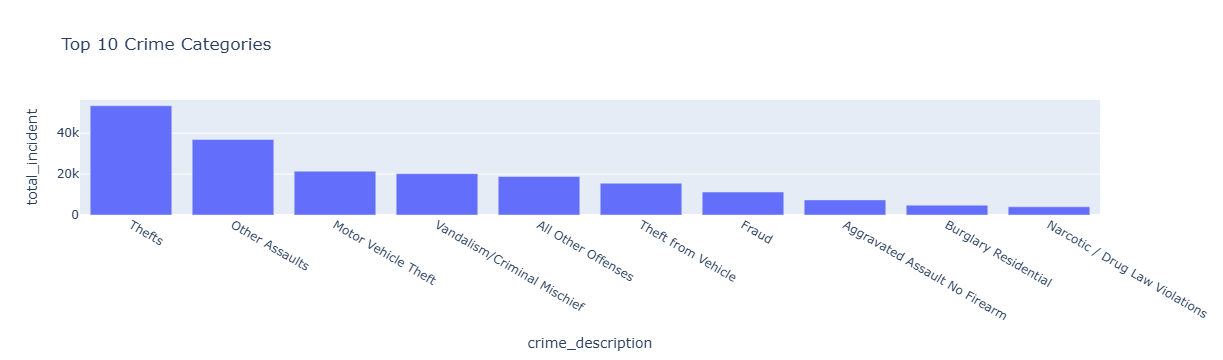

In [179]:
import plotly.express as px

fig = px.bar(
    top_crime.head(10),
    x="crime_description",
    y="total_incident",
    title="Top 10 Crime Categories"
)

fig.show()

## Analisis Tren Kejahatan

In [180]:
crime_time = fact_crime.merge(
    dim_time,
    on="time_id",
    how="left"
)

In [181]:
trend_year = (
    crime_time.groupby("year")
    ["total_incident"]
    .sum()
    .reset_index()
)

trend_year

,year,total_incident
0,2023,65178
1,2024,153603


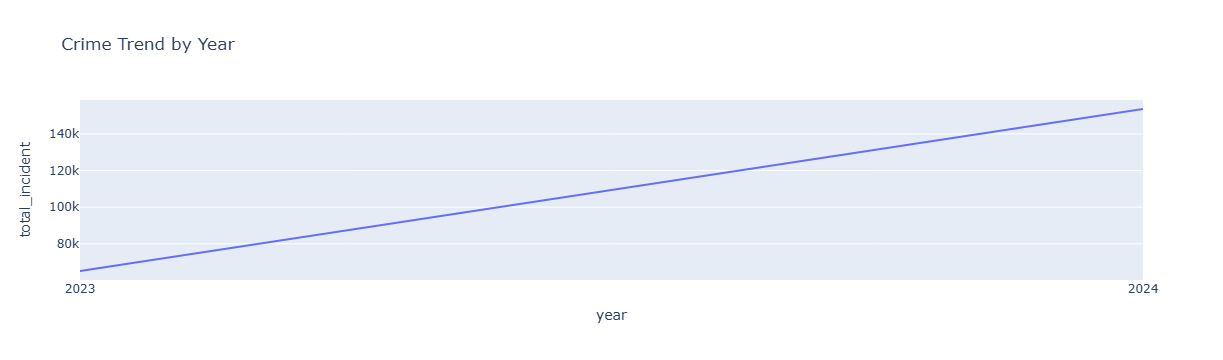

In [182]:
fig = px.line(
    trend_year,
    x="year",
    y="total_incident",
    title="Crime Trend by Year"
)

fig.show()

## Analisis Distrik Rawan

In [183]:
crime_district = fact_crime.merge(
    dim_district,
    on="district_id",
    how="left"
)

In [184]:
district_rank = (
    crime_district.groupby("dc_dist")
    ["total_incident"]
    .sum()
    .reset_index()
)

district_rank = district_rank.sort_values(
    by="total_incident",
    ascending=False
)

district_rank.head(10)

,dc_dist,total_incident
10,15,17782
15,22,15521
7,9,14562
17,25,13663
16,24,13655
14,19,13442
9,14,13084
1,2,12693
8,12,12323
19,35,11893


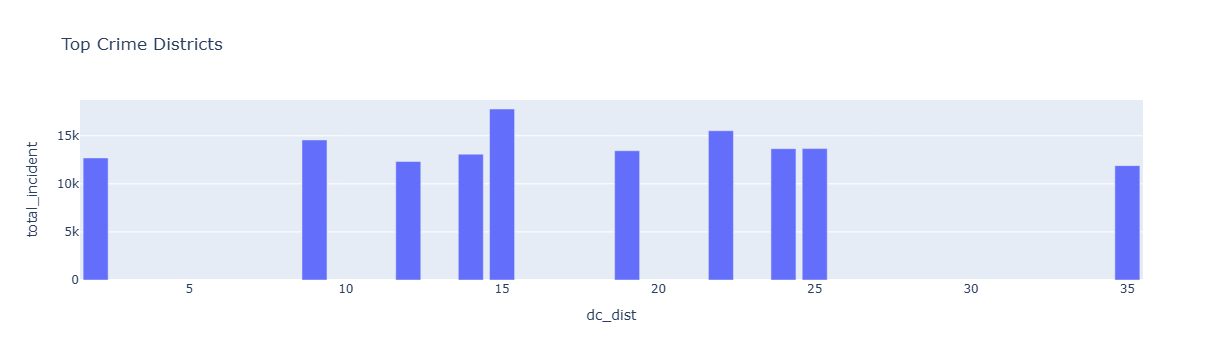

In [185]:
fig = px.bar(
    district_rank.head(10),
    x="dc_dist",
    y="total_incident",
    title="Top Crime Districts"
)

fig.show()

## Analisis Jam Rawan

In [186]:
crime_hour = (
    crime_time.groupby("hour")
    ["total_incident"]
    .sum()
    .reset_index()
)

crime_hour

,hour,total_incident
0,0,10713
1,1,8928
2,10,2250
3,11,4011
4,12,8505
5,13,12342
6,14,13633
7,15,13930
8,16,14138
9,17,14080


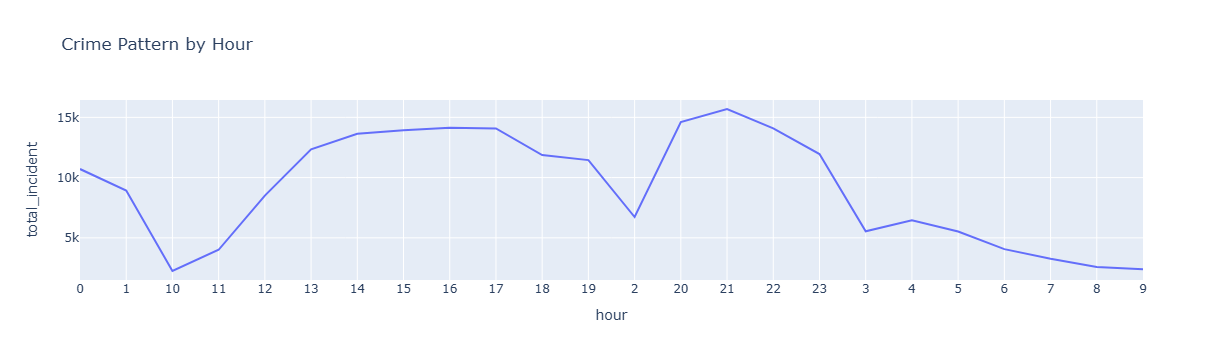

In [187]:
fig = px.line(
    crime_hour,
    x="hour",
    y="total_incident",
    title="Crime Pattern by Hour"
)

fig.show()

# Slice Analysis

In [188]:
crime_slice = (
    fact_crime
    .merge(dim_time, on="time_id", how="left")
    .merge(dim_crime, on="crime_id", how="left")
)
crime_2024 = crime_slice[
    crime_slice["year"] == "2024"
]
slice_2024 = (
    crime_2024.groupby("crime_description")
    ["total_incident"]
    .sum()
    .reset_index()
)
slice_2024 = slice_2024.sort_values(
    by="total_incident",
    ascending=False
)
slice_2024.head(10)

,crime_description,total_incident
27,Thefts,38882
18,Other Assaults,26356
15,Motor Vehicle Theft,13906
2,All Other Offenses,13752
29,Vandalism/Criminal Mischief,13484
26,Theft from Vehicle,10281
10,Fraud,8282
1,Aggravated Assault No Firearm,5377
5,Burglary Residential,3287
16,Narcotic / Drug Law Violations,2899


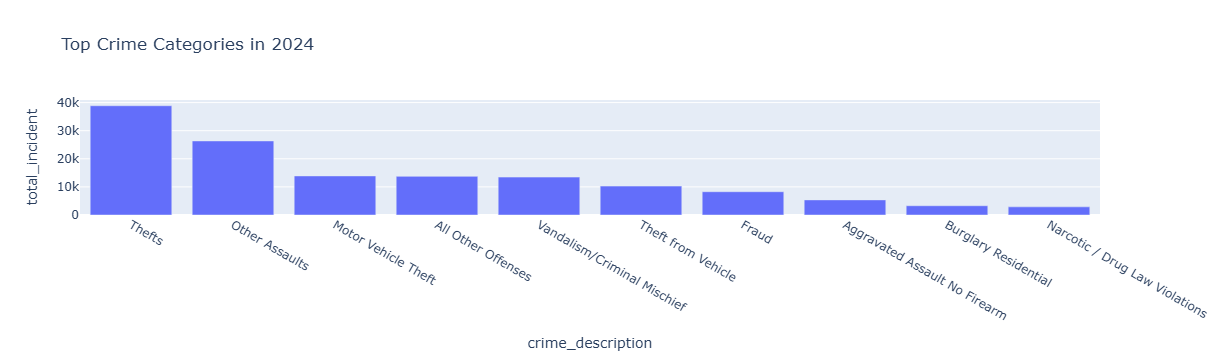

In [189]:
import plotly.express as px

fig = px.bar(
    slice_2024.head(10),
    x="crime_description",
    y="total_incident",
    title="Top Crime Categories in 2024"
)

fig.show()

In [190]:
crime_slice = (
    fact_crime
    .merge(dim_time, on="time_id", how="left")
    .merge(dim_crime, on="crime_id", how="left")
)
crime_2023 = crime_slice[
    crime_slice["year"] == "2023"
]
slice_2023 = (
    crime_2023.groupby("crime_description")
    ["total_incident"]
    .sum()
    .reset_index()
)
slice_2023 = slice_2023.sort_values(
    by="total_incident",
    ascending=False
)
slice_2023.head(10)

,crime_description,total_incident
28,Thefts,14524
19,Other Assaults,10531
16,Motor Vehicle Theft,7527
30,Vandalism/Criminal Mischief,6705
27,Theft from Vehicle,5267
2,All Other Offenses,5077
10,Fraud,2951
1,Aggravated Assault No Firearm,2009
5,Burglary Residential,1528
0,Aggravated Assault Firearm,1227


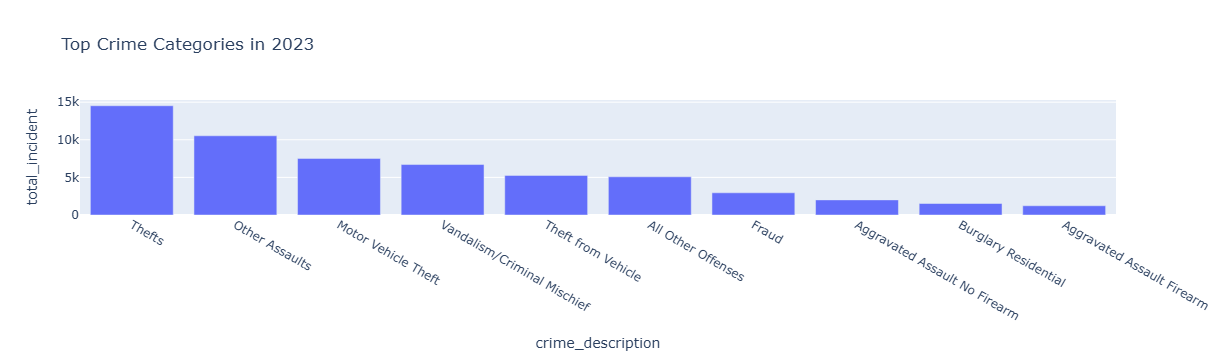

In [191]:
fig = px.bar(
    slice_2023.head(10),
    x="crime_description",
    y="total_incident",
    title="Top Crime Categories in 2023"
)

fig.show()

# Dice Analysis

In [192]:
crime_dice = (
    fact_crime
    .merge(dim_time, on="time_id", how="left")
    .merge(dim_crime, on="crime_id", how="left")
    .merge(dim_district, on="district_id", how="left")
)
dice_result = crime_dice[
    (crime_dice["year"] == "2024") &
    (crime_dice["dc_dist"] == 19)
]
dice_result = (
    dice_result.groupby("crime_description")
    ["total_incident"]
    .sum()
    .reset_index()
)
dice_result = dice_result.sort_values(
    by="total_incident",
    ascending=False
)
dice_result.head(10)

,crime_description,total_incident
16,Other Assaults,2477
24,Thefts,2204
25,Vandalism/Criminal Mischief,894
13,Motor Vehicle Theft,777
2,All Other Offenses,658
10,Fraud,508
1,Aggravated Assault No Firearm,379
23,Theft from Vehicle,372
0,Aggravated Assault Firearm,223
5,Burglary Residential,203


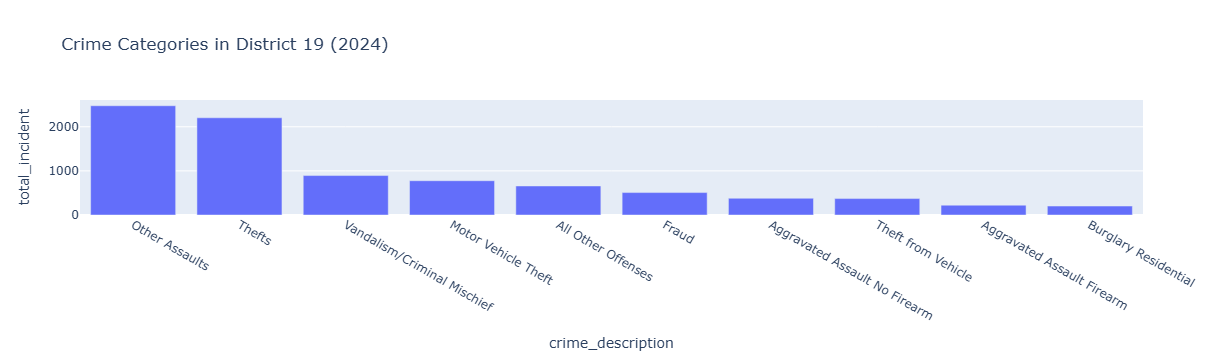

In [193]:
import plotly.express as px

fig = px.bar(
    dice_result.head(10),
    x="crime_description",
    y="total_incident",
    title="Crime Categories in District 19 (2024)"
)

fig.show()

# Drill Dwon Analysis

In [194]:
crime_time = (
    fact_crime
    .merge(dim_time, on="time_id", how="left")
)

In [195]:
drill_year = (
    crime_time.groupby("year")
    ["total_incident"]
    .sum()
    .reset_index()
)

drill_year

,year,total_incident
0,2023,65178
1,2024,153603


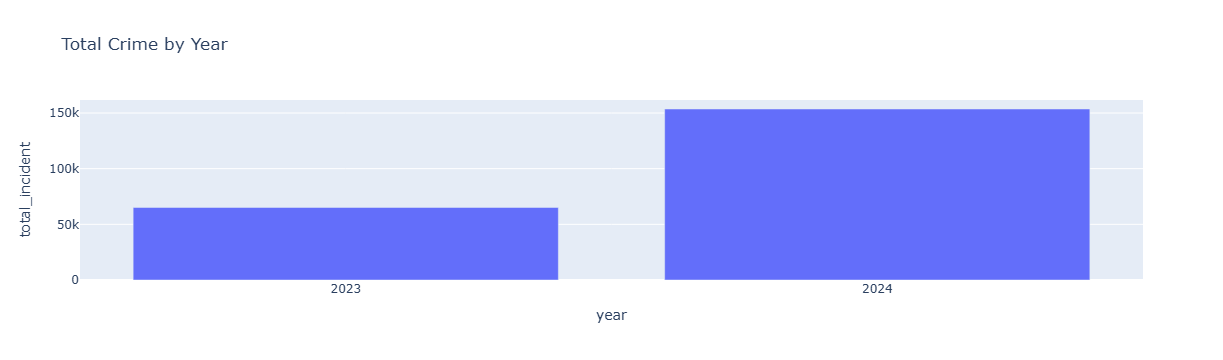

In [196]:
import plotly.express as px

fig = px.bar(
    drill_year,
    x="year",
    y="total_incident",
    title="Total Crime by Year"
)

fig.show()

In [197]:
drill_month = (
    crime_time.groupby(["year", "month"])
    ["total_incident"]
    .sum()
    .reset_index()
)

drill_month.head(20)

,year,month,total_incident
0,2023,1,13245
1,2023,10,139
2,2023,11,9971
3,2023,12,11876
4,2023,2,12040
5,2023,3,12722
6,2023,4,4988
7,2023,5,43
8,2023,6,33
9,2023,7,34


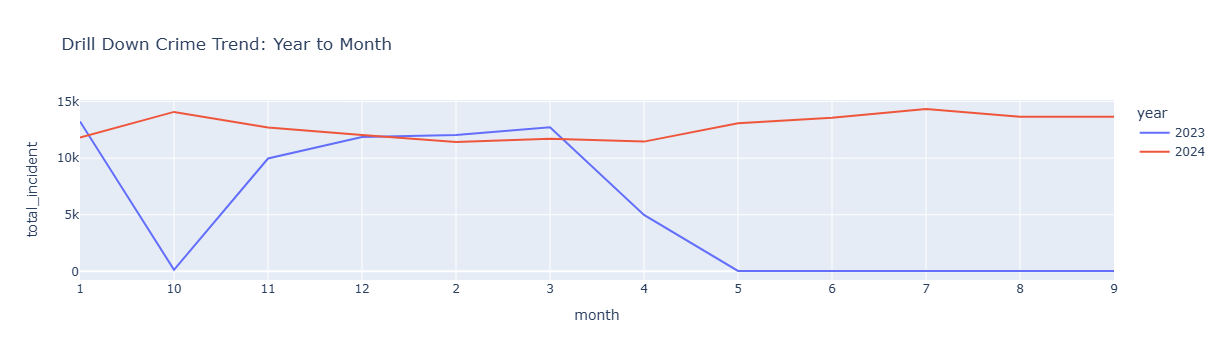

In [198]:
fig = px.line(
    drill_month,
    x="month",
    y="total_incident",
    color="year",
    title="Drill Down Crime Trend: Year to Month"
)

fig.show()

In [199]:
drill_day = (
    crime_time.groupby(["year", "month", "day"])
    ["total_incident"]
    .sum()
    .reset_index()
)

drill_day.head(20)

,year,month,day,total_incident
0,2023,1,1,332
1,2023,1,10,452
2,2023,1,11,464
3,2023,1,12,458
4,2023,1,13,458
5,2023,1,14,374
6,2023,1,15,336
7,2023,1,16,409
8,2023,1,17,488
9,2023,1,18,483


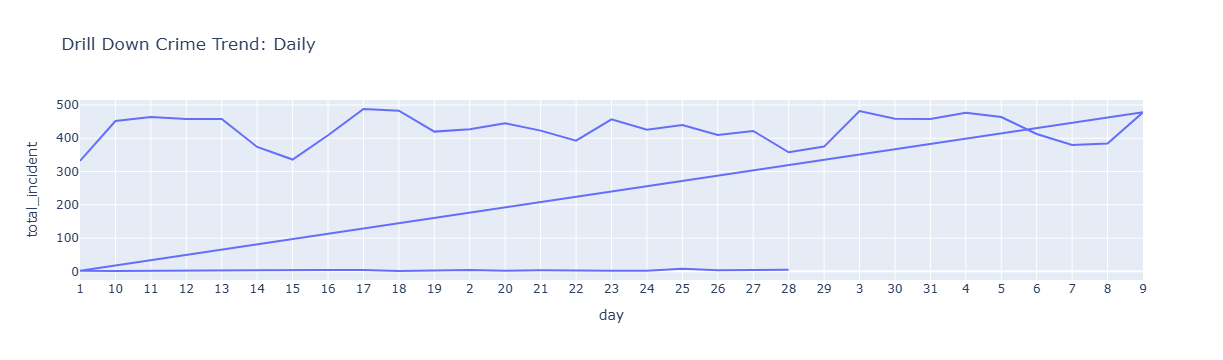

In [200]:
fig = px.line(
    drill_day.head(50),
    x="day",
    y="total_incident",
    title="Drill Down Crime Trend: Daily"
)

fig.show()

In [201]:
drill_hour = (
    crime_time.groupby(["year", "month", "day", "hour"])
    ["total_incident"]
    .sum()
    .reset_index()
)

drill_hour.head(20)

,year,month,day,hour,total_incident
0,2023,1,1,0,12
1,2023,1,1,1,12
2,2023,1,1,10,8
3,2023,1,1,11,2
4,2023,1,1,12,4
5,2023,1,1,13,7
6,2023,1,1,14,9
7,2023,1,1,15,20
8,2023,1,1,16,18
9,2023,1,1,17,20


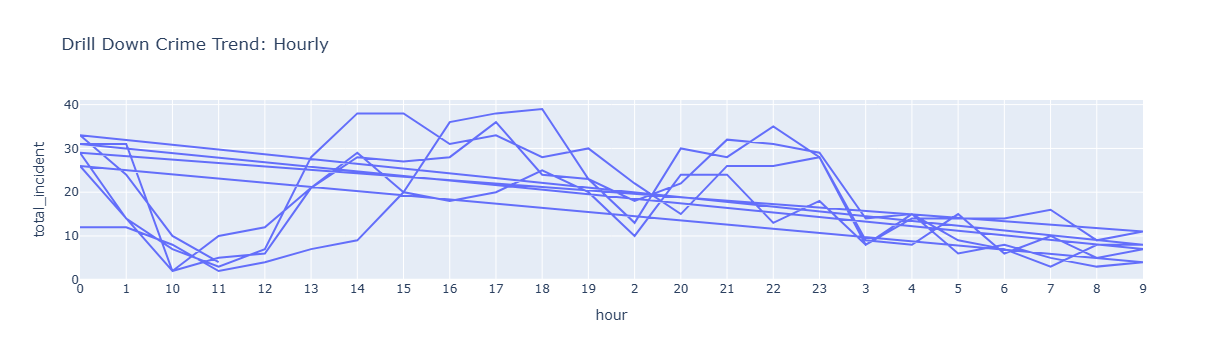

In [202]:
fig = px.line(
    drill_hour.head(100),
    x="hour",
    y="total_incident",
    title="Drill Down Crime Trend: Hourly"
)

fig.show()

# Roll-up Analysis

In [203]:
crime_time = (
    fact_crime
    .merge(dim_time, on="time_id", how="left")
)

In [204]:
rollup_hour = (
    crime_time.groupby(["year", "month", "day", "hour"])
    ["total_incident"]
    .sum()
    .reset_index()
)

rollup_hour.head(20)

,year,month,day,hour,total_incident
0,2023,1,1,0,12
1,2023,1,1,1,12
2,2023,1,1,10,8
3,2023,1,1,11,2
4,2023,1,1,12,4
5,2023,1,1,13,7
6,2023,1,1,14,9
7,2023,1,1,15,20
8,2023,1,1,16,18
9,2023,1,1,17,20


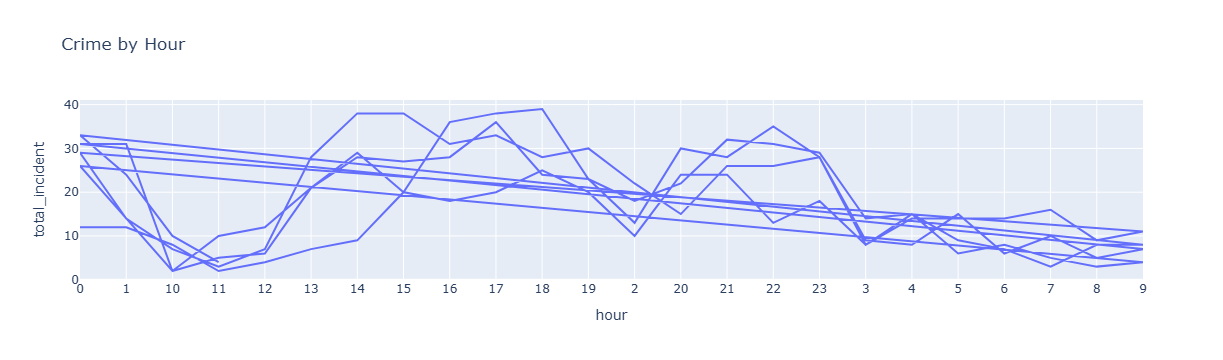

In [205]:
import plotly.express as px

fig = px.line(
    rollup_hour.head(100),
    x="hour",
    y="total_incident",
    title="Crime by Hour"
)

fig.show()

In [206]:
rollup_day = (
    crime_time.groupby(["year", "month", "day"])
    ["total_incident"]
    .sum()
    .reset_index()
)

rollup_day.head(20)

,year,month,day,total_incident
0,2023,1,1,332
1,2023,1,10,452
2,2023,1,11,464
3,2023,1,12,458
4,2023,1,13,458
5,2023,1,14,374
6,2023,1,15,336
7,2023,1,16,409
8,2023,1,17,488
9,2023,1,18,483


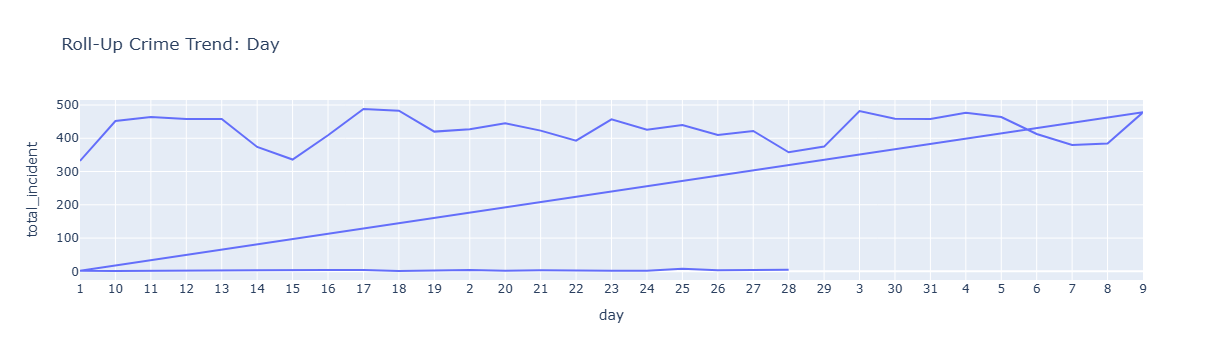

In [207]:
fig = px.line(
    rollup_day.head(50),
    x="day",
    y="total_incident",
    title="Roll-Up Crime Trend: Day"
)

fig.show()

In [208]:
rollup_month = (
    crime_time.groupby(["year", "month"])
    ["total_incident"]
    .sum()
    .reset_index()
)

rollup_month.head(20)

,year,month,total_incident
0,2023,1,13245
1,2023,10,139
2,2023,11,9971
3,2023,12,11876
4,2023,2,12040
5,2023,3,12722
6,2023,4,4988
7,2023,5,43
8,2023,6,33
9,2023,7,34


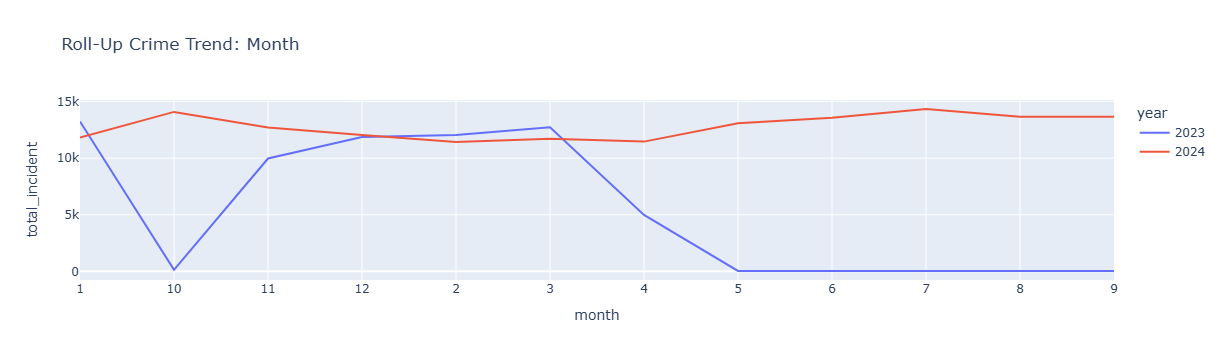

In [209]:
fig = px.line(
    rollup_month,
    x="month",
    y="total_incident",
    color="year",
    title="Roll-Up Crime Trend: Month"
)

fig.show()

In [210]:
rollup_year = (
    crime_time.groupby("year")
    ["total_incident"]
    .sum()
    .reset_index()
)

rollup_year

,year,total_incident
0,2023,65178
1,2024,153603


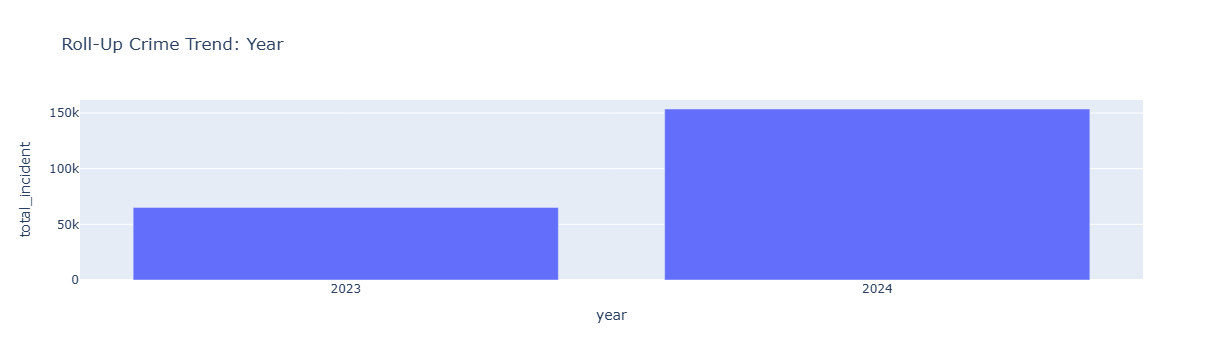

In [211]:
fig = px.bar(
    rollup_year,
    x="year",
    y="total_incident",
    title="Roll-Up Crime Trend: Year"
)

fig.show()

In [ ]:
session.link()